5350 Thesis in Economics

Andres Cruz 25199 & Klara Holmer 25037 

Code for Grundskola and Gymnasieskola

In [1]:
# Importing Libraries
import numpy as np 
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Step 1 - Importing ExcelFiles and Concatenating DataFrames

# --- Gymnasieskola  Årskurs 1 or Upper Secondary School Year 10 --- 

# Defining the full path to the Excel file in the new folder
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Processed Data/gymnasieskola_ämnen.xlsx'

# Read all sheets at once into a dictionary
sheets = ['English', 'Mathematics', 'Swedish']
gymnasieskola_data = pd.read_excel(pathname, sheet_name=sheets)

# Unpack the dictionary into separate variables if needed
gymnasieskola_data_english = gymnasieskola_data['English']
gymnasieskola_data_mathematics = gymnasieskola_data['Mathematics']
gymnasieskola_data_swedish = gymnasieskola_data['Swedish']

# --- Lower Secondary School Year 9 --- 

# Defining the full path to the Excel file in the new folder
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Processed Data/grundskola_ämnen.xlsx'

# Read all sheets at once into a dictionary
sheets = ['English', 'Mathematics', 'Swedish']
grundskola_data = pd.read_excel(pathname, sheet_name=sheets)

# Unpack the dictionary into separate variables if needed
grundskola_data_english = grundskola_data['English']
grundskola_data_mathematics = grundskola_data['Mathematics']
grundskola_data_swedish_data = grundskola_data['Swedish']

# --- Concatenating --- 

# Engelska
school_data_english = pd.concat([gymnasieskola_data_english, grundskola_data_english], ignore_index=True)

# Matematik
school_data_mathematics = pd.concat([gymnasieskola_data_mathematics, grundskola_data_mathematics], ignore_index=True)

# Svenska
school_data_swedish = pd.concat([gymnasieskola_data_swedish, grundskola_data_swedish_data], ignore_index=True)

# List of DataFrames
dataframes = [school_data_english, school_data_mathematics, school_data_swedish]

gymnasieskola_data_english

In [3]:
# Step 2 -  Adding County ID 

# Defining the full path to the Excel file in the new folder
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/kommun_I/georef-sweden-kommun.xlsx'

# Read all sheets at once into a dictionary
kommun_data = pd.read_excel(pathname, sheet_name=0)

# List of new names 
new_names = [
    'geo_point',            # Column 1 Geo Point
    'geo_shape',            # Column 2 Geo Shape
    'year',                 # Column 3 Year
    'county_ID',            # Column 4 Län code
    'school_county',        # Column 5 Län name
    'municipality_ID',      # Column 6 Kommun code
    'school_municipality',  # Column 7 Kommun name
    'area_code',            # Column 8 ISO 3166-3 Area code
    'type',                 # Column 9 Type
    ]

# List of new names 
columns_to_drop = [
    'geo_point',            # Column 1 Geo Point
    'geo_shape',            # Column 2 Geo Shape
    'year',                 # Column 3 Year
    'area_code',            # Column 8 ISO 3166-3 Area code
    'type',                 # Column 9 Type
    ]

# Applying the new names 
kommun_data.columns = new_names

# Drop the specified columns
kommun_data.drop(columns=columns_to_drop, axis=1, inplace=True)

# Define the join keys
join_keys = ['school_municipality', 'municipality_ID']

# Apply merging and store the results back in the list
dataframes = [pd.merge(df, kommun_data, on=join_keys, how='left') for df in dataframes]

# Unpacking the list 
school_data_english, school_data_mathematics, school_data_swedish = dataframes
school_data_english


,school_ID,school_municipality,municipality_ID,type_of_ownership,academic_year,educational_stage,school_size,total_school_students,graduating_students,share_female_students,...,total_fulltime_teachers,total_fulltime_certified_teachers,share_fulltime_certified_teachers,total_active_teachers,total_active_certified_teachers,share_active_certified_teachers,share_students_A_E_eng,share_students_F_eng,county_ID,school_county
0,74776778,Alingsås,1489,Kommunal,2014/15,gymnasieskola,100-199,135.0,44.0,43.0,...,7.7,6.1,78.8,20.0,15.0,75.0,97.7,2.3,14,Västra Götalands län
1,18345915,Alingsås,1489,Kommunal,2014/15,gymnasieskola,200-299,211.0,41.0,30.0,...,14.2,13.8,97.2,29.0,27.0,93.1,100.0,0.0,14,Västra Götalands län
2,68229719,Alingsås,1489,Kommunal,2014/15,gymnasieskola,100-199,155.0,45.0,63.0,...,13.1,12.6,95.9,23.0,21.0,91.3,100.0,0.0,14,Västra Götalands län
3,61004230,Alingsås,1489,Kommunal,2014/15,gymnasieskola,50-99,94.0,44.0,66.0,...,8.8,6.0,68.3,16.0,12.0,75.0,100.0,0.0,14,Västra Götalands län
4,71262305,Arboga,1984,Kommunal,2014/15,gymnasieskola,100-199,183.0,63.0,50.0,...,23.2,15.9,68.4,27.0,19.0,70.4,100.0,0.0,19,Västmanlands län
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19472,50308658,Överkalix,2513,Kommunal,2021/22,grundskola,100-199,118.0,16.0,45.0,...,14.8,7.9,53.0,19.0,11.0,57.9,75.0,25.0,25,Norrbottens län
19473,13342436,Överkalix,2513,Enskild,2021/22,grundskola,50-99,54.0,NaN,44.0,...,6.1,1.7,27.6,7.0,5.0,71.4,NaN,NaN,25,Norrbottens län
19474,46252858,Övertorneå,2518,Enskild,2021/22,grundskola,50-99,62.0,11.0,52.0,...,6.9,2.3,33.2,10.0,4.0,40.0,100.0,0.0,25,Norrbottens län
19475,90707437,Övertorneå,2518,Kommunal,2021/22,grundskola,50-99,72.0,12.0,56.0,...,7.9,3.6,45.4,16.0,10.0,62.5,100.0,0.0,25,Norrbottens län


In [4]:
# Step 3 - Exporting 

# Defining the full path where the Excel file will be saved
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Processed Data/school_data_ämnen.xlsx'

# Exporting all the tables created into one Excel File 
with pd.ExcelWriter(pathname) as writer:
    school_data_english.to_excel(writer, sheet_name = 'English', index=False)
    school_data_mathematics.to_excel(writer, sheet_name = 'Mathematics', index=False)
    school_data_swedish.to_excel(writer, sheet_name = 'Swedish', index=False)

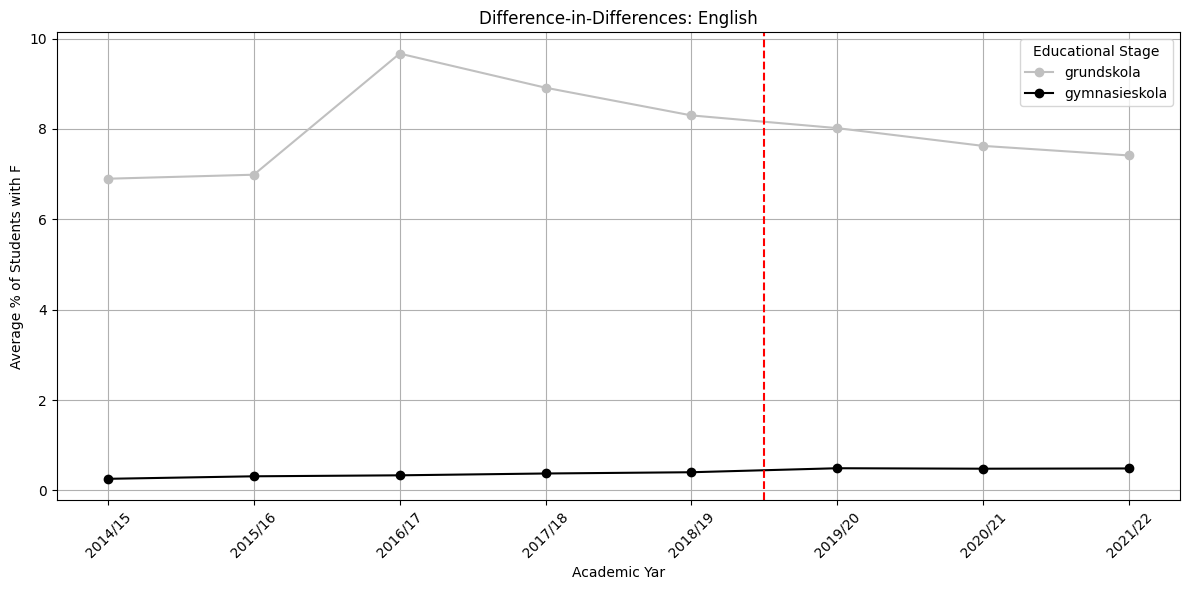

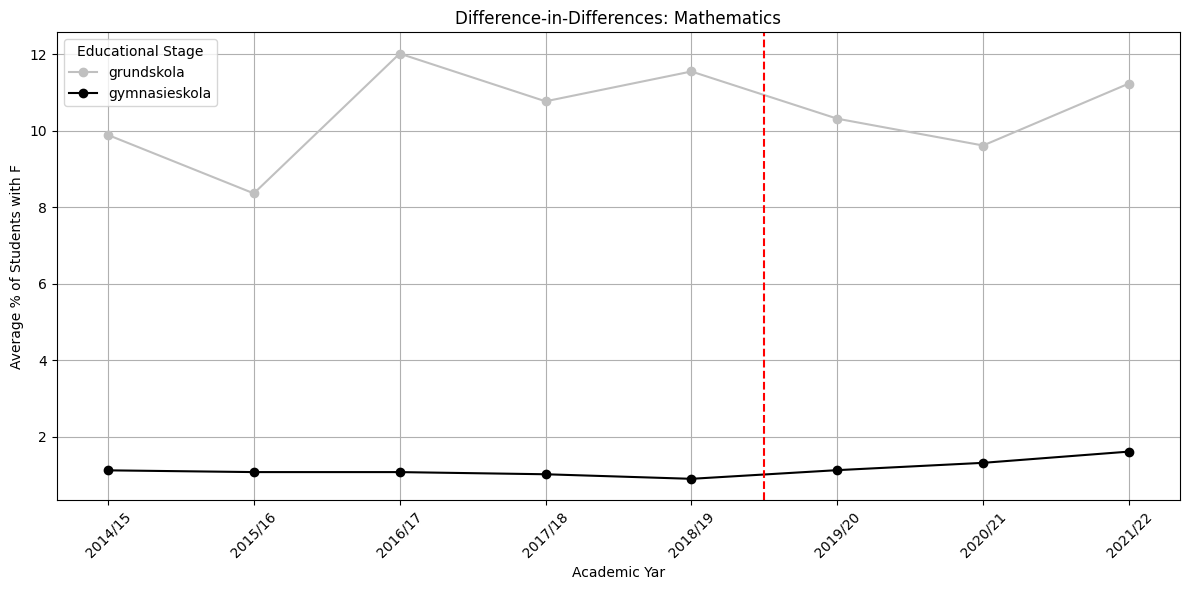

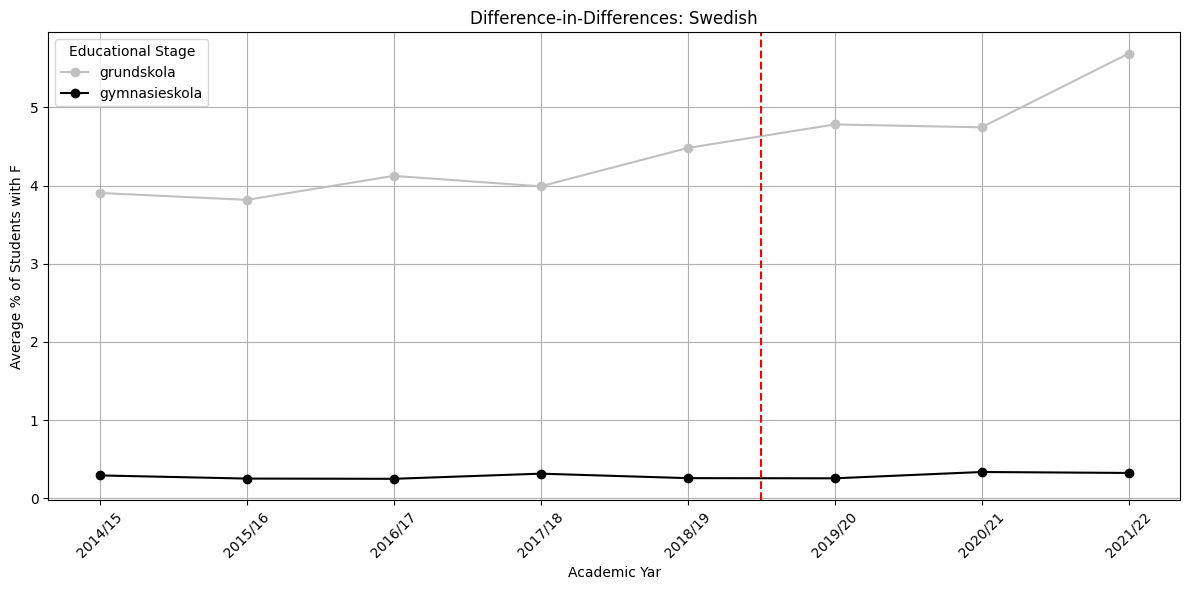

,school_ID,school_municipality,municipality_ID,type_of_ownership,academic_year,educational_stage,school_size,total_school_students,graduating_students,share_female_students,...,total_fulltime_certified_teachers,share_fulltime_certified_teachers,total_active_teachers,total_active_certified_teachers,share_active_certified_teachers,share_students_A_E_eng,share_students_F_eng,county_ID,school_county,year_numeric
0,74776778,Alingsås,1489,Kommunal,2014/15,gymnasieskola,100-199,135.0,44.0,43.0,...,6.1,78.8,20.0,15.0,75.0,97.7,2.3,14,Västra Götalands län,15
1,18345915,Alingsås,1489,Kommunal,2014/15,gymnasieskola,200-299,211.0,41.0,30.0,...,13.8,97.2,29.0,27.0,93.1,100.0,0.0,14,Västra Götalands län,15
2,68229719,Alingsås,1489,Kommunal,2014/15,gymnasieskola,100-199,155.0,45.0,63.0,...,12.6,95.9,23.0,21.0,91.3,100.0,0.0,14,Västra Götalands län,15
3,61004230,Alingsås,1489,Kommunal,2014/15,gymnasieskola,50-99,94.0,44.0,66.0,...,6.0,68.3,16.0,12.0,75.0,100.0,0.0,14,Västra Götalands län,15
4,71262305,Arboga,1984,Kommunal,2014/15,gymnasieskola,100-199,183.0,63.0,50.0,...,15.9,68.4,27.0,19.0,70.4,100.0,0.0,19,Västmanlands län,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19472,50308658,Överkalix,2513,Kommunal,2021/22,grundskola,100-199,118.0,16.0,45.0,...,7.9,53.0,19.0,11.0,57.9,75.0,25.0,25,Norrbottens län,22
19473,13342436,Överkalix,2513,Enskild,2021/22,grundskola,50-99,54.0,NaN,44.0,...,1.7,27.6,7.0,5.0,71.4,NaN,NaN,25,Norrbottens län,22
19474,46252858,Övertorneå,2518,Enskild,2021/22,grundskola,50-99,62.0,11.0,52.0,...,2.3,33.2,10.0,4.0,40.0,100.0,0.0,25,Norrbottens län,22
19475,90707437,Övertorneå,2518,Kommunal,2021/22,grundskola,50-99,72.0,12.0,56.0,...,3.6,45.4,16.0,10.0,62.5,100.0,0.0,25,Norrbottens län,22


In [5]:
# Step 1 - Difference-in-Difference Plots


def process_and_plot_did(data, variable, title, treatment_year=19.5):
    """
    Processes the dataset, ensuring all years are represented, and generates a Difference-in-Differences plot.
    
    Parameters:
    - data: Pandas DataFrame containing the data. It must include a 'läsår' column with string values in the format 'yyyy/yy'.
    - variable: Column name for the dependent variable to be plotted.
    - title: Title for the plot.
    - treatment_year: The numeric part (yy) of the läsår when the treatment/intervention occurred.
    """
    
    # Create a numeric version of 'academic_year' using the yy part
    data['year_numeric'] = data['academic_year'].apply(lambda x: int(x.split('/')[1]))
    
    # Aggregate data by year_numeric, academic_year, and school type (educational_stage)
    grouped_df = data.groupby(['year_numeric', 'academic_year', 'educational_stage'], as_index=False)[variable].mean()
    
    # Create a full range of numeric years for continuity in the plot
    all_years = pd.DataFrame({
        'year_numeric': range(grouped_df['year_numeric'].min(), grouped_df['year_numeric'].max() + 1)
    })
    
    # Create a mapping from numeric year to academic_year using available data
    mapping = dict(zip(grouped_df['year_numeric'], grouped_df['academic_year']))
    
    # Generate the plot
    plt.figure(figsize=(12, 6))
    
    for educational_stage, subset in grouped_df.groupby('educational_stage'):
        # Merge with all_years to fill in any missing years
        subset = all_years.merge(subset, on='year_numeric', how='left')
        subset['educational_stage'] = educational_stage  # preserve educational_stage
        
        # Assign colors: blue for gymnasieskola, green for grundskola
        if educational_stage.lower() == 'gymnasieskola':
            color = 'black'
        elif educational_stage.lower() == 'grundskola':
            color = 'silver'
        else:
            color = None  # default color for any other skolform
        
        # Plot using the numeric year for the x-axis
        plt.plot(subset['year_numeric'], subset[variable], marker='o', linestyle='-', label=educational_stage, color=color)
    
    # Add a vertical line indicating the treatment year
    plt.axvline(x=treatment_year, color='red', linestyle='--')
    
    # Set custom x-ticks: use the numeric years but label them with the läsår format.
    xticks = all_years['year_numeric']
    xlabels = [mapping.get(x, f"{2000 + x - 1}/{x:02d}") for x in xticks]
    plt.xticks(xticks, xlabels, rotation=45)
    
    # Configure the plot
    plt.title(f'Difference-in-Differences: {title}')
    plt.xlabel('Academic Yar')
    plt.ylabel('Average % of Students with F')
    plt.legend(title='Educational Stage')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Apply the function to the provided dataframes
process_and_plot_did(school_data_english, 'share_students_F_eng', 'English')
process_and_plot_did(school_data_mathematics, 'share_students_F_ma', 'Mathematics')
process_and_plot_did(school_data_swedish, 'share_students_F_sv', 'Swedish')
school_data_english